# Block-PC1 Manhattans + QQ — SNP / smallindel / SV (density-invariant)

kMate GrENE-Net phase-1 replication, **last_gen** (355 pools). Each LD block reduced to its dominant haplotype axis (**PC1** of the block AF matrix), then **Kendall-τ(PC1, bio1)** — **one test per block, invariant to SNP count**. y = -log10(PC1 p). CAM5 (`2_1265`) green, the Chr4-12Mb peak (`4_2519`) orange.

**Caveat:** PC1-Kendall is *density-invariant* but **not structure-corrected** — pool pseudoreplication inflates absolute significance. The QQ plot below quantifies that (genomic inflation λ ≫ 1). Use this for ranking / the density question, not calibrated p. Block `4_2519` staying near the top (rank 3) is the point: its dominance is *not* a panel-density artifact.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

PCDIR = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/pc1"
CLASSES = ["snp", "smallindel", "sv"]
CHROMS = [f"Chr{i}" for i in range(1, 6)]
MARK = {"2_1265": ("CAM5", "green"), "4_2519": ("4_2519 (Chr4-12Mb)", "darkorange")}

def load(cls):
    w = pd.read_csv(f"{PCDIR}/pc1_{cls}_gen9_bio1.csv")
    w["block"] = w["block"].astype(str); w["chrom"] = w["chrom"].astype(str)
    w = w[w["chrom"].isin(CHROMS) & w["pval"].notna()].copy()
    w["mlogp"] = -np.log10(w["pval"].clip(lower=1e-300))
    return w

def lambda_gc(p):
    p = np.clip(np.asarray(p, float), 1e-300, 1)
    return np.median(chi2.isf(p, 1)) / chi2.isf(0.5, 1)

## Manhattan (one PC1 test per block)

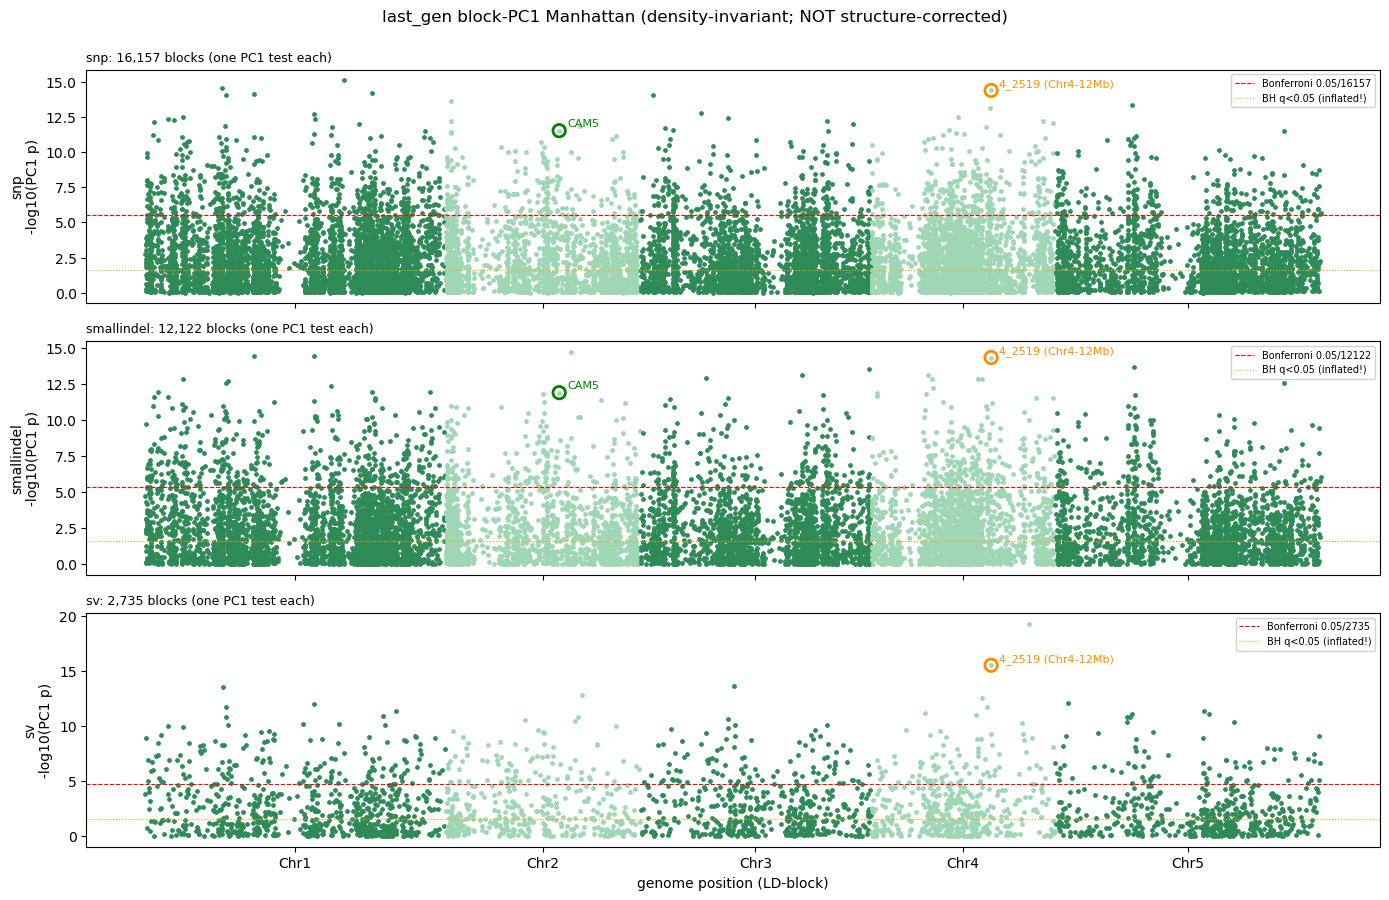

In [2]:
allpos = pd.concat([load(c)[["chrom", "pos"]] for c in CLASSES])
chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
offset  = chrom_max.cumsum().shift(1).fillna(0)
centers = offset + chrom_max / 2

fig, axes = plt.subplots(len(CLASSES), 1, figsize=(14, 9), sharex=True)
colors = ["#2e8b57", "#9fd6b4"]
for ax, cls in zip(axes, CLASSES):
    w = load(cls); w["x"] = w["pos"] + w["chrom"].map(offset); n = len(w)
    p = np.sort(w["pval"].to_numpy()); m = len(p)
    bh = np.where(p <= 0.05 * (np.arange(1, m + 1) / m))[0]; bh_p = p[bh.max()] if len(bh) else None
    for i, ch in enumerate(CHROMS):
        s = w[w["chrom"] == ch]; ax.scatter(s["x"], s["mlogp"], s=6, c=colors[i % 2], rasterized=True)
    ax.axhline(-np.log10(0.05 / n), color="red", lw=0.8, ls="--", label=f"Bonferroni 0.05/{n}")
    if bh_p: ax.axhline(-np.log10(bh_p), color="orange", lw=0.8, ls=":", label="BH q<0.05 (inflated!)")
    for blk, (lab, col) in MARK.items():
        r = w[w["block"] == blk]
        if len(r):
            ax.scatter(r["x"], r["mlogp"], s=80, facecolors="none", edgecolors=col, linewidths=2, zorder=5)
            ax.annotate(lab, (r["x"].iloc[0], r["mlogp"].iloc[0]), color=col, fontsize=8,
                        xytext=(6, 3), textcoords="offset points")
    ax.set_ylabel(f"{cls}\n-log10(PC1 p)"); ax.legend(loc="upper right", fontsize=7, framealpha=0.9)
    ax.set_title(f"{cls}: {n:,} blocks (one PC1 test each)", fontsize=9, loc="left")
axes[-1].set_xticks(centers); axes[-1].set_xticklabels(CHROMS); axes[-1].set_xlabel("genome position (LD-block)")
fig.suptitle("last_gen block-PC1 Manhattan (density-invariant; NOT structure-corrected)", y=0.995)
plt.tight_layout(); plt.show()

## QQ plot — observed vs expected -log10(p)

Under the null (no association / well-calibrated), points follow the diagonal. Points lifting **above** the diagonal across the whole range = inflation. The genomic inflation factor **λ** (median χ²₁ ratio) quantifies it; λ ≈ 1 is calibrated, λ ≫ 1 means the test is anticonservative — here driven by **pool pseudoreplication**, not real signal, since PC1-Kendall has no structure correction.

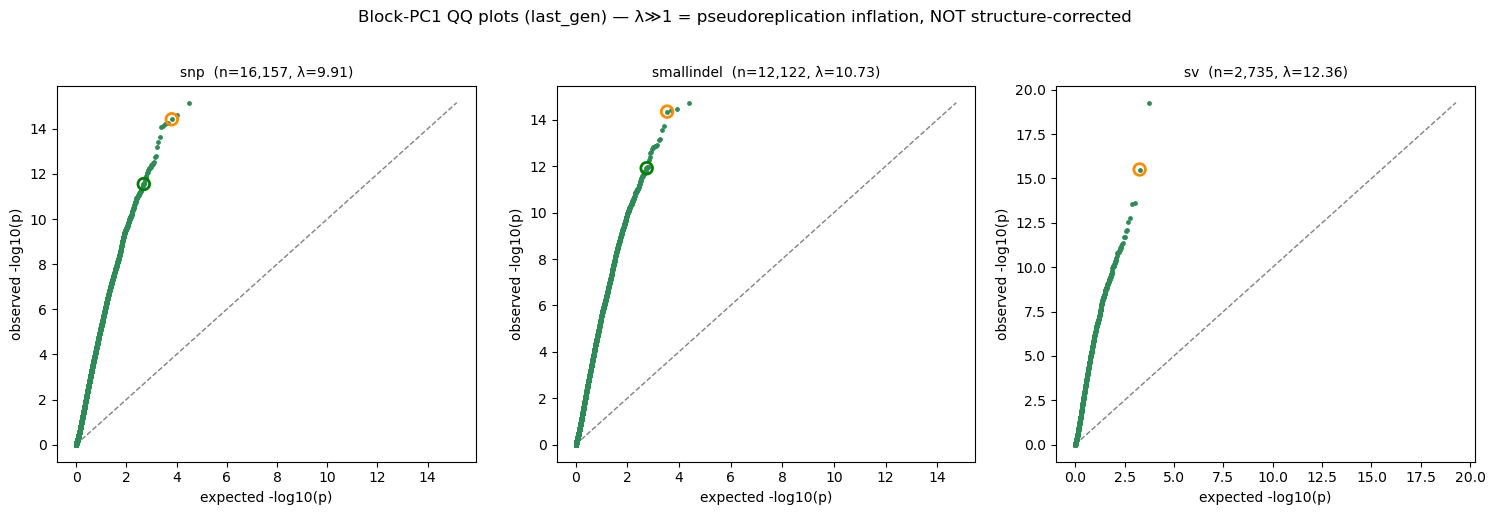

In [3]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 5))
for ax, cls in zip(axes, CLASSES):
    w = load(cls)
    p = np.sort(w["pval"].to_numpy()); n = len(p)
    obs = -np.log10(np.clip(p, 1e-300, 1))
    exp = -np.log10((np.arange(1, n + 1) - 0.5) / n)
    lam = lambda_gc(p)
    mx = max(exp.max(), obs.max())
    ax.plot([0, mx], [0, mx], color="grey", lw=1, ls="--", zorder=1)
    ax.scatter(exp, obs, s=6, c="#2e8b57", rasterized=True, zorder=2)
    # mark CAM5 / 4_2519 on the QQ
    for blk, (lab, col) in MARK.items():
        r = w.index[w["block"] == blk]
        if len(r):
            rank = (w["pval"] < w.loc[r[0], "pval"]).sum()
            ax.scatter(-np.log10((rank + 0.5) / n), -np.log10(max(w.loc[r[0], "pval"], 1e-300)),
                       s=70, facecolors="none", edgecolors=col, linewidths=2, zorder=3)
    ax.set_title(f"{cls}  (n={n:,}, \u03bb={lam:.2f})", fontsize=10)
    ax.set_xlabel("expected -log10(p)"); ax.set_ylabel("observed -log10(p)")
fig.suptitle("Block-PC1 QQ plots (last_gen) \u2014 \u03bb\u226b1 = pseudoreplication inflation, NOT structure-corrected", y=1.02)
plt.tight_layout(); plt.show()

## Key blocks: PC1 rank + variance-explained

In [4]:
rows = []
for cls in CLASSES:
    w = load(cls).sort_values("pval").reset_index(drop=True); n = len(w)
    for blk, (lab, _) in MARK.items():
        r = w.index[w["block"] == blk]
        if len(r):
            i = int(r[0]); rr = w.loc[i]
            rows.append(dict(cls=cls, block=blk, label=lab, n_blocks=n, PC1_rank=i+1,
                             n_snps=int(rr.n_snps), pc1_var_expl=rr.pc1_var_explained,
                             tau=round(rr.tau,3), p=f"{rr.pval:.2e}"))
        else:
            rows.append(dict(cls=cls, block=blk, label=lab, n_blocks=n, PC1_rank=None))
pd.DataFrame(rows)

,cls,block,label,n_blocks,PC1_rank,n_snps,pc1_var_expl,tau,p
0,snp,2_1265,CAM5,16157,33.0,16.0,0.8168,-0.252,2.80e-12
1,snp,4_2519,4_2519 (Chr4-12Mb),16157,3.0,1168.0,0.5779,-0.284,3.77e-15
2,smallindel,2_1265,CAM5,12122,22.0,7.0,0.7396,-0.256,1.22e-12
3,smallindel,4_2519,4_2519 (Chr4-12Mb),12122,4.0,389.0,0.6383,0.283,4.44e-15
4,sv,2_1265,CAM5,2735,NaN,NaN,NaN,NaN,NaN
5,sv,4_2519,4_2519 (Chr4-12Mb),2735,2.0,17.0,0.3686,0.295,3.12e-16
